In [29]:
ON_COLAB = True
USE_DRIVE = False

In [30]:
if ON_COLAB:
    # ----- for colab
    from zipfile import ZipFile
    !gdown 1TkdWr42pf3BN02xW9diBcldNsC7NYpNd
    !gdown 1ScJ0sAt01sQdVXA7wHZuvmkf7fXhU5Zq
    with ZipFile("images.zip", 'r') as zObject:
        zObject.extractall(path="dataset")

    with ZipFile("annotations.zip", 'r') as zObject:
        zObject.extractall(path="dataset")

Downloading...
From (original): https://drive.google.com/uc?id=1TkdWr42pf3BN02xW9diBcldNsC7NYpNd
From (redirected): https://drive.google.com/uc?id=1TkdWr42pf3BN02xW9diBcldNsC7NYpNd&confirm=t&uuid=192a551b-d20b-4770-8814-ba47eafdd9b7
To: /content/images.zip
100% 792M/792M [00:12<00:00, 65.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1ScJ0sAt01sQdVXA7wHZuvmkf7fXhU5Zq
To: /content/annotations.zip
100% 18.5k/18.5k [00:00<00:00, 55.1MB/s]


In [31]:
from pathlib import Path
from PIL import Image
from torch import Tensor
from torch.utils.data import Dataset
from typing import List, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import DataLoader
import torch.optim as optim
import time

import matplotlib.pyplot as plt


In [32]:
class OxfordPetDataset(Dataset):
    def __init__(self, split: str, transform=None) -> None:
        super().__init__()

        if USE_DRIVE:
            self.root = Path("drive") / "MyDrive" / "Colab Notebooks" / "cv" / "dataset"
        elif ON_COLAB:
            self.root = Path("dataset")
        else:
            self.root = Path("/home/liam/Desktop/magistrale/computervision/progetto/modulo_due/ipcv-assignment-2/dataset")
        self.split = split
        self.names, self.labels = self._get_names_and_labels()
        self.transform = transform

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx) -> Tuple[Tensor, int]:
        img_path = self.root / "images" / f"{self.names[idx]}.jpg"
        img = Image.open(img_path).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

    def get_num_classes(self) -> int:
        return max(self.labels) + 1

    def _get_names_and_labels(self) -> Tuple[List[str], List[int]]:
        names = []
        labels = []

        with open(self.root / "annotations" / f"{self.split}.txt") as f:
            for line in f:
                name, label = line.replace("\n", "").split(" ")
                names.append(name),
                labels.append(int(label) - 1)

        return names, labels

In [33]:
import random
from torchvision import transforms
from torchvision.transforms import functional as tF
from torchvision.transforms import RandomPerspective


class Random90DegreeRotation:
    """Custom transform for 90-degree rotations with specific probabilities."""
    def __call__(self, img):
        prob = random.random()
        if prob < 0.5:
            return img  # no rotation
        elif prob < 0.75:
            return tF.rotate(img, angle=-90)
        else:
            return tF.rotate(img, angle=90)

class OuterRandomCrop:
    """Custom transform to randomly crop the same amount of pixels from each side of the image."""
    def __init__(self, max_pixels_to_crop):
        """
        Args:
            max_pixels_to_crop (int): The maximum number of pixels to subtract from each side of the image.
        """
        self.max_pixels_to_crop = max_pixels_to_crop

    def __call__(self, img):
        # decides whether to apply the crop (75% chance)
        if random.random() < 0.25:
            return img

        # randomly select the number of pixels to crop (between 0 and max_pixels_to_crop)
        pixels_to_crop = random.randint(0, self.max_pixels_to_crop)

        width, height = img.size
        crop_left = pixels_to_crop
        crop_top = pixels_to_crop
        crop_width = width - 2 * pixels_to_crop
        crop_height = height - 2 * pixels_to_crop

        if crop_width <= 0 or crop_height <= 0:
            raise ValueError("The number of pixels to crop is too large for the image dimensions.")

        return tF.crop(img, top=crop_top, left=crop_left, height=crop_height, width=crop_width)



convert_compatible = transforms.Compose([
    transforms.Resize((224, 224)),     # Deterministic resize
    transforms.ToTensor(),             # Format conversion only
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # image net normalization values
])

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

transform_data_augmentation = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.2)
])

# Create datasets
train_dataset = OxfordPetDataset('train', transform=transform_data_augmentation)
val_dataset = OxfordPetDataset('val', transform=convert_compatible)
test_dataset = OxfordPetDataset('test', transform=convert_compatible)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

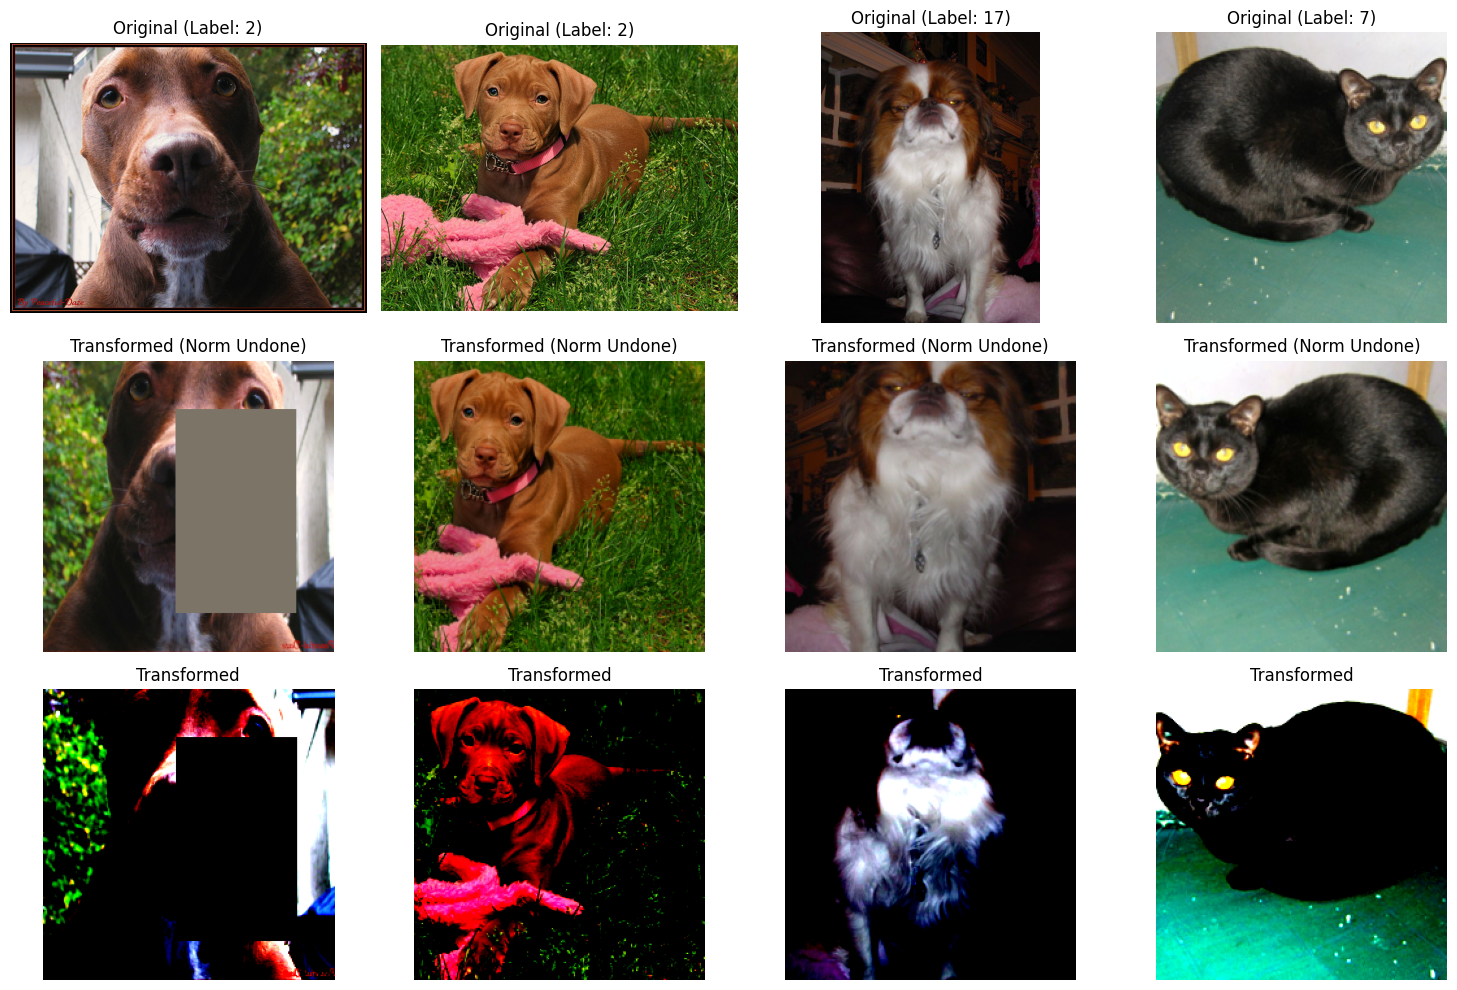

In [34]:
import matplotlib.pyplot as plt
import random

# Function to display images
def display_image_comparison(dataset, num_images=4):
    fig, axes = plt.subplots(3, num_images, figsize=(15, 10))  # 3 rows, num_images columns

    for i in range(num_images):
        # Randomly select an image from the dataset
        idx = random.randint(0, len(dataset) - 1)

        # Access the raw image without applying the dataset's transform
        img_path = dataset.root / "images" / f"{dataset.names[idx]}.jpg"
        original_img = Image.open(img_path).convert("RGB")  # Load as PIL image
        label = dataset.labels[idx]

        # Apply your transformation
        transformed_with_norm = transform_data_augmentation(original_img)  # Fully transformed with normalization

        # Undo normalization for visualization
        mean = [0.485, 0.456, 0.406]
        std = [0.229, 0.224, 0.225]
        transformed_with_norm_np = transformed_with_norm.permute(1, 2, 0).numpy()
        transformed_no_norm_np = std * transformed_with_norm_np + mean  # Undo normalization
        transformed_no_norm_np = transformed_no_norm_np.clip(0, 1)

        # Display original image
        axes[0, i].imshow(original_img)
        axes[0, i].set_title(f"Original (Label: {label})")
        axes[0, i].axis("off")

        # Display transformed image with normalization undone
        axes[1, i].imshow(transformed_no_norm_np)
        axes[1, i].set_title("Transformed (Norm Undone)")
        axes[1, i].axis("off")

        # Display fully transformed image (with normalization)
        axes[2, i].imshow(transformed_with_norm_np)
        axes[2, i].set_title("Transformed")
        axes[2, i].axis("off")

    plt.tight_layout()
    plt.show()

# Call the function to display the comparison
display_image_comparison(train_dataset, num_images=4)

ho tolto mixup e cutmix

ho tolto "num_workers" dal TrainConfig che non veniva usato

ho tolto batch_size e la funzione one_hot e soft_cross_entropy perchè senza mixup e cutmix non venivano usati

(copilot): *EMA: nel tuo codice non influisce sull’addestramento perché non viene usato per validazione/salvataggio; puoi rimuoverlo*. ho rimosso anche la funzione deep_copy_model

ho tolto anche accuracy_top1 non veniva usata

ho impostato amp a false

ho tolto il label smoothing

IMPORTANTE: provo con la mia funzione di training. mi sembra che la differenza più grossa sia lo scheduler onecyclelr quindi metto quello

una cosa che manca è il clip dei pesi, che non ho messo qua


----------

ATTENZIONE ho completamente rimosso i cbam dal modello. ora è una resnet normale

In [35]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs=10,
    one_cycle_max_lr = 4e-3,
    show_all_minibatches_loss=False
):
    """
    Trains a PyTorch model and evaluates it on a validation set.

    Args:
        model (torch.nn.Module): The model to train.
        train_loader (DataLoader): DataLoader for the training dataset.
        val_loader (DataLoader): DataLoader for the validation dataset.
        criterion (torch.nn.Module): Loss function to optimize.
        optimizer (torch.optim.Optimizer): Optimizer for updating model weights.
        num_epochs (int): Number of epochs to train the model.
        show_all_minibatches_loss (bool): Can be 'no', 'brief', 'verbose'. Determines how many mini batch losses are printed

    Returns:
        tuple: A tuple containing:
            - train_losses (list): List of average training losses per epoch.
            - train_accuracies (list): List of training accuracies per epoch.
            - train_class_accuracies (list): List of per-class training accuracies per epoch.
            - val_losses (list): List of validation losses per epoch.
            - val_accuracies (list): List of validation accuracies per epoch.
            - val_class_accuracies (list): List of per-class validation accuracies per epoch.
            - train_epoch_times (list): Tempo (s) della sola fase di training per epoca.
            - total_epoch_times (list): Tempo (s) dell’intero ciclo per epoca (train + validazione/metriche).
    """

    train_losses = []
    train_accuracies = []
    train_class_accuracies = []
    val_losses = []
    val_accuracies = []
    val_class_accuracies = []
    train_epoch_times = []
    total_epoch_times = []

    # Get number of classes from the model's output layer
    num_classes = model.fc.out_features

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Setup OneCycleLR scheduler (per-batch). Uses current optimizer lr as max_lr.
    try:
        steps_per_epoch = len(train_loader)
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer, max_lr=one_cycle_max_lr, epochs=num_epochs, steps_per_epoch=steps_per_epoch
        )
        scheduler_per_batch = True
    except Exception:
        scheduler = None
        scheduler_per_batch = False

    for epoch in range(num_epochs):
        t_epoch_start = time.time()

        # --- Training phase ---
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        train_class_correct = torch.zeros(num_classes, dtype=torch.long)
        train_class_total = torch.zeros(num_classes, dtype=torch.long)

        tot_batches = train_loader.__len__()
        t_train_start = time.time()
        for batch_idx, (batch_images, batch_labels) in enumerate(train_loader):
            batch_images = batch_images.to(device)
            batch_labels = batch_labels.to(device)

            # Zero gradients from previous iteration
            optimizer.zero_grad()

            outputs = model(batch_images)
            loss = criterion(outputs, batch_labels)
            if show_all_minibatches_loss != 'no':
                if show_all_minibatches_loss == 'verbose' or batch_idx in [40, 80]:
                    print(f"Batch {batch_idx + 1}/{tot_batches}: loss = {loss.item():.4f}")

            # Compute gradients
            loss.backward()

            # Update weights
            optimizer.step()

            # Step scheduler per-batch (if configured)
            if scheduler_per_batch and scheduler is not None:
                scheduler.step()

            running_loss += loss.item()

            # Calculate training accuracy
            _, predicted = torch.max(outputs.data, 1)
            total_train += batch_labels.size(0)
            correct_train += (predicted == batch_labels).sum().item()

            # Per-class accuracy for training
            for i in range(batch_labels.size(0)):
                label = batch_labels[i]
                train_class_total[label] += 1
                if predicted[i] == label:
                    train_class_correct[label] += 1

        # Time
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        train_time = time.time() - t_train_start
        train_epoch_times.append(train_time)

        train_accuracy = 100 * correct_train / total_train
        train_loss = running_loss / len(train_loader)

        # Training Per-Class Accuracies
        epoch_train_class_accuracies = []
        for i in range(num_classes):
            if train_class_total[i] > 0:
                class_acc = train_class_correct[i].item() / train_class_total[i].item()
            else:
                class_acc = 0.0  # no samples for this class
            epoch_train_class_accuracies.append(class_acc)

        # --- Validation ---
        model.eval()
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0

        # Initialize per-class counters for validation
        val_class_correct = torch.zeros(num_classes, dtype=torch.long)
        val_class_total = torch.zeros(num_classes, dtype=torch.long)

        with torch.no_grad():  # don't compute gradients for validation
            for batch_images, batch_labels in val_loader:
                batch_images = batch_images.to(device)
                batch_labels = batch_labels.to(device)

                outputs = model(batch_images)
                loss = criterion(outputs, batch_labels)
                running_val_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                total_val += batch_labels.size(0)
                correct_val += (predicted == batch_labels).sum().item()

                # Validation Per-Class Accuracies
                for i in range(batch_labels.size(0)):
                    label = batch_labels[i]
                    val_class_total[label] += 1
                    if predicted[i] == label:
                        val_class_correct[label] += 1

        val_accuracy = 100 * correct_val / total_val
        val_loss = running_val_loss / len(val_loader)

        # Validation Per-Class Accuracies
        epoch_val_class_accuracies = []
        for i in range(num_classes):
            if val_class_total[i] > 0:
                class_acc = val_class_correct[i].item() / val_class_total[i].item()
            else:
                class_acc = 0.0  # no samples for this class
            epoch_val_class_accuracies.append(class_acc)

        # Time
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        total_time = time.time() - t_epoch_start
        total_epoch_times.append(total_time)

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        train_class_accuracies.append(epoch_train_class_accuracies)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)
        val_class_accuracies.append(epoch_val_class_accuracies)

        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.2f}%, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}% | "
              f"Epoch Time: {total_time:.2f}s")

        print('-'*20)

    return (train_losses, train_accuracies, train_class_accuracies,
            val_losses, val_accuracies, val_class_accuracies,
            train_epoch_times, total_epoch_times)

# resnet model

questa cosa in realtà non serve. tanto il modello lo prendo da internet. però non so così se vuoi ti puoi guardare la mia architettura. se vuoi cancellalo

In [ ]:
import torch
import math
import torch.nn as nn


class BasicBlock(nn.Module):
    """A basic residual block for ResNet."""
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
          identity = self.downsample(x)

        out += identity
        out = self.relu(out)
        return out


class ResNet(nn.Module):
    """Custom ResNet architecture."""
    def __init__(self, block, layers, num_classes=37,
            base_widths=(24, 48, 96, 192)):
        super(ResNet, self).__init__()
        self.in_channels = 24
        c1, c2, c3, c4 = base_widths

        self.stem = nn.Sequential(
            nn.Conv2d(3, c1, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(c1),
            nn.ReLU(inplace=True),
            nn.Conv2d(c1, c1, kernel_size=3, stride=2, padding=1, bias=False),  # downsample qui
            nn.BatchNorm2d(c1),
            nn.ReLU(inplace=True),
        )

        # Residual layers
        self.layer1 = self._make_layer(block, c1, layers[0])
        self.layer2 = self._make_layer(block, c2, layers[1], stride=2)
        self.layer3 = self._make_layer(block, c3, layers[2], stride=2)
        self.layer4 = self._make_layer(block, c4, layers[3], stride=2)

        # Fully connected layer
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(c4, num_classes)

    def _make_layer(self, block, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

        layers = []
        layers.append(block(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(block(out_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)

        return x


# def resnet18(num_classes=37):
#     return ResNet(BasicBlock, [2, 2, 2, 2], num_classes=num_classes)


# num_classes = 37
# model_resnet = resnet18(num_classes=num_classes)

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# model_resnet = model_resnet.to(device)

# from torchsummary import summary
# summary(model_resnet, input_size=(3, 224, 224))

## pre trained model

In [37]:
from torchvision import models
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

weights = models.ResNet18_Weights.IMAGENET1K_V1
model_resnet = models.resnet18(weights=weights).to(device)


num_classes = 37
in_feats = model_resnet.fc.in_features
model_resnet.fc = torch.nn.Linear(in_feats, num_classes).to(device)

primo allenamento: identico al mio modello della parte 1. 80 epoche

ho copiato questa cella in fondo al notebook, dove carico i pesi derivati da questo allenamento e ne faccio partire un altro, modificando la funzione di training per cambiare (nella mia prova) lo scheduler

In [38]:
lr = 3e-4
one_cycle_max_lr = 4e-3
weight_decay = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model_resnet.parameters(), lr=lr, weight_decay=weight_decay)

train_losses, train_accuracies, train_class_accuracies, val_losses, val_accuracies, val_class_accuracies, train_epoch_times, total_epoch_times = train_model(
    model_resnet, train_loader, val_loader, criterion, optimizer, num_epochs=80,
    one_cycle_max_lr=one_cycle_max_lr, show_all_minibatches_loss='no'
)

Epoch [1/80], Train Loss: 1.4112, Train Acc: 66.69%, Val Loss: 0.7267, Val Acc: 79.61% | Epoch Time: 49.81s
--------------------
Epoch [2/80], Train Loss: 0.4738, Train Acc: 88.80%, Val Loss: 0.6175, Val Acc: 81.08% | Epoch Time: 49.31s
--------------------
Epoch [3/80], Train Loss: 0.3478, Train Acc: 90.49%, Val Loss: 0.7189, Val Acc: 78.30% | Epoch Time: 48.20s
--------------------
Epoch [4/80], Train Loss: 0.4071, Train Acc: 88.72%, Val Loss: 1.3673, Val Acc: 62.05% | Epoch Time: 49.03s
--------------------
Epoch [5/80], Train Loss: 0.5081, Train Acc: 84.33%, Val Loss: 1.2527, Val Acc: 63.20% | Epoch Time: 49.22s
--------------------
Epoch [6/80], Train Loss: 0.6142, Train Acc: 80.62%, Val Loss: 1.6811, Val Acc: 53.93% | Epoch Time: 48.95s
--------------------
Epoch [7/80], Train Loss: 0.7270, Train Acc: 77.60%, Val Loss: 2.2473, Val Acc: 45.64% | Epoch Time: 49.18s
--------------------
Epoch [8/80], Train Loss: 0.7540, Train Acc: 77.11%, Val Loss: 1.6753, Val Acc: 57.25% | Epoch Ti

In [39]:

def get_preds_and_trues(model, dataset, batch_size=32, device=None):
    """
    Return (y_true, y_pred) as 1-D numpy arrays (dtype=int) suitable for sklearn.metrics.confusion_matrix.

    Args:
        model (torch.nn.Module): model with loaded weights (will be moved to `device`).
        dataset (torch.utils.data.Dataset): dataset that yields (input, label) pairs.
        batch_size (int): batch size used to create an internal DataLoader (shuffle=False).
        device (torch.device or None): device for inference; if None, inferred from the model.

    Returns:
        (y_true, y_pred): two 1-D numpy arrays of integer labels with the same length.
    """
    import numpy as np
    import torch
    from torch.utils.data import DataLoader

    device = device or (next(model.parameters()).device if any(True for _ in model.parameters()) else torch.device('cpu'))
    model = model.to(device)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    model.eval()
    all_true = []
    all_pred = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            preds = logits.argmax(dim=1).cpu().numpy()

            # yb can be torch.Tensor or list/np.array
            if isinstance(yb, torch.Tensor):
                y_np = yb.cpu().numpy()
            else:
                import numpy as _np
                y_np = _np.asarray(yb)

            all_true.append(y_np)
            all_pred.append(preds)

    if len(all_true) == 0:
        return np.array([], dtype=int), np.array([], dtype=int)

    y_true = np.concatenate(all_true).ravel().astype(int)
    y_pred = np.concatenate(all_pred).ravel().astype(int)

    # sanity check: stessa lunghezza
    if y_true.shape[0] != y_pred.shape[0]:
        raise ValueError(f"Mismatch lengths: y_true={y_true.shape[0]} y_pred={y_pred.shape[0]}")

    return y_true, y_pred

In [40]:
import os
import pickle

output_dir = "results"

os.makedirs(output_dir, exist_ok=True)

y_true, y_pred = get_preds_and_trues(model_resnet, test_dataset, device=device)

history = {}
history['train_loss'] = train_losses
history['train_acc'] = train_accuracies
history['train_class_acc'] = train_class_accuracies
history['val_loss'] = val_losses
history['val_acc'] = val_accuracies
history['val_class_acc'] = val_class_accuracies
history['train_epoch_times'] = train_epoch_times
history['total_epoch_times'] = total_epoch_times
history['y_pred'] = y_pred
history['y_true'] = y_true

with open(os.path.join(output_dir, "history.pkl"), "wb") as f:
    pickle.dump(history, f)


torch.save(model_resnet, "resnet_18_complete_training_weights")

## losses and accuracies

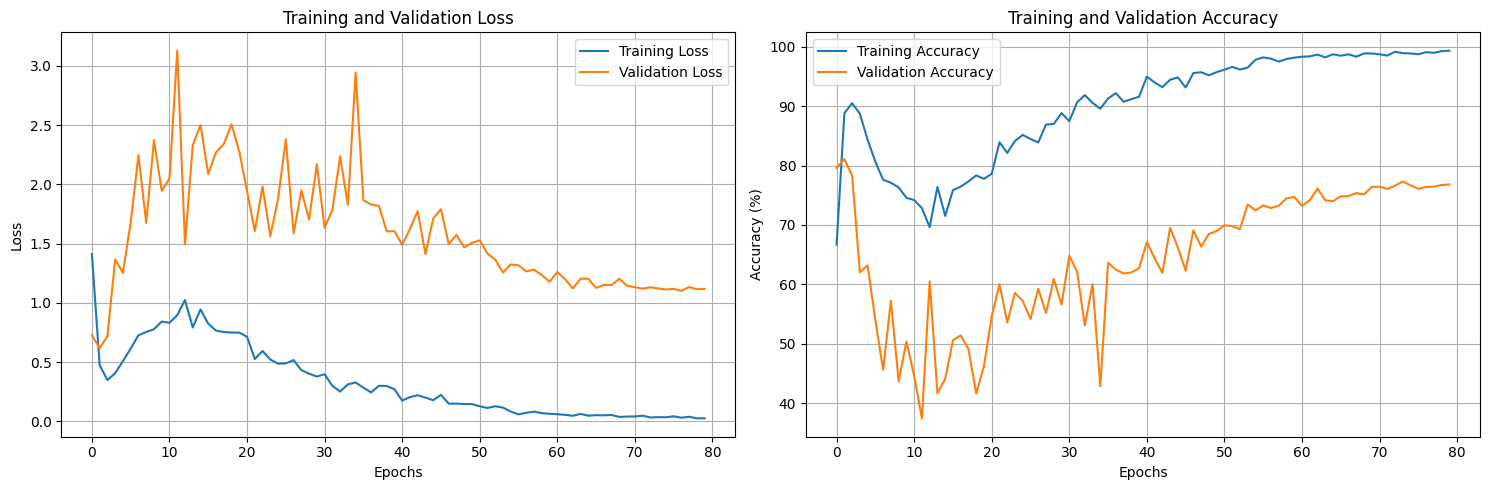

In [41]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history['train_loss'], label='Training Loss')
axes[0].plot(history['val_loss'], label='Validation Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_acc'], label='Training Accuracy')
axes[1].plot(history['val_acc'], label='Validation Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Test set accuracy

In [42]:
# Load the saved model weights and map them to the CPU
# model_resnet.load_state_dict(torch.load("resnet_18_complete_training_weights", map_location=torch.device('cpu')))
# model_resnet = model_resnet.to(device)  # Move the model to the appropriate device (CPU or GPU)

# Set the model to evaluation mode
# model_resnet.load_state_dict(torch.load('best_small_cbam.pt', map_location=device))
model_resnet.eval()

# Initialize variables to track correct predictions and total samples
correct = 0
total = 0

# Disable gradient computation for evaluation
with torch.no_grad():
    for batch_images, batch_labels in test_loader:
        # Move data to the same device as the model
        batch_images = batch_images.to(device)
        batch_labels = batch_labels.to(device)

        # Forward pass: get predictions
        outputs = model_resnet(batch_images)
        _, predicted = torch.max(outputs.data, 1)

        # Update total and correct counts
        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()

# Calculate and print the accuracy
test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 78.44%


## model architecture image

In [43]:
!pip install torchview

In [44]:
import importlib.util, shutil, sys, subprocess

def _ensure(package):
    if importlib.util.find_spec(package) is None:
        print(f"{package} not found, installing...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

_ensure("torchview")

if shutil.which("dot") is None:
    print("Warning: 'dot' (graphviz) not found in PATH.")

from torchview import draw_graph
import torch

def save_model_graph(model, filename="resnet", input_size=(1, 3, 224, 224), device=None, depth=5):
    model.eval()
    device = device or next(model.parameters()).device
    g = draw_graph(
        model,
        input_size=input_size,
        expand_nested=True,
        depth=depth,
        device=device
    )
    out_path = g.visual_graph.render(filename, format="png", cleanup=True)
    print(f"Salvato: {out_path}")
    return out_path

_ = save_model_graph(model_resnet, filename="results/resnet_architecture", input_size=(1, 3, 224, 224), device=device, depth=5)

Salvato: results/resnet_architecture.png


## confusion matrix

In [45]:
def plot_cm_sklearn(model, dataset, class_names=None, normalize=None, batch_size=32, device=None, figsize=None, cmap='Reds', include_values=True, title='Confusion Matrix', save_path=None, dpi=150):
    """
    Uses sklearn.metrics.ConfusionMatrixDisplay.
    - Accepts a model and a dataset and computes y_true / y_pred internally.
    - normalize: None | 'true' | 'pred' | 'all'
    Returns (fig, ax).
    """
    import numpy as np
    import torch
    from torch.utils.data import DataLoader
    from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
    import matplotlib.pyplot as plt

    # device and dataloader
    device = device or (next(model.parameters()).device if any(True for _ in model.parameters()) else torch.device('cpu'))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    # collect y_true, y_pred
    model.eval()
    all_true, all_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = model(x)
            pred = logits.argmax(1).cpu().numpy()
            # y can be a torch.Tensor or a list/np.array
            if isinstance(y, torch.Tensor):
                y_np = y.cpu().numpy()
            else:
                y_np = np.asarray(y)
            all_true.append(y_np)
            all_pred.append(pred)

    if len(all_true) == 0:
        raise ValueError("Empty dataset or dataloader returned no batches.")
    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)

    # compute cm_raw and cm_display (apply normalization if requested)
    cm_raw = confusion_matrix(y_true, y_pred, labels=None, normalize=None)
    if normalize in ('true', 'pred', 'all'):
        # use sklearn for normalized vectors (returns floats)
        cm_display = confusion_matrix(y_true, y_pred, labels=None, normalize=normalize)
    else:
        cm_display = cm_raw.copy()

    # if sklearn returned proportions (0..1) and you want percentages, keep as float (visualization)
    # figure sizing
    num_classes = cm_display.shape[0]
    if figsize is None:
        size = max(6, num_classes * 0.22)
        figsize = (size, size)
    fig, ax = plt.subplots(figsize=figsize)

    # show with ConfusionMatrixDisplay
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_display, display_labels=class_names)
    # values_format=None uses the internal formatting; for custom annotations use seaborn or custom code
    disp.plot(ax=ax, include_values=include_values, cmap=cmap, xticks_rotation='vertical', values_format=None)

    ax.set_title(title)
    plt.tight_layout()
    if save_path:
        import os
        save_dir = os.path.dirname(save_path)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
    plt.show()
    return fig, ax

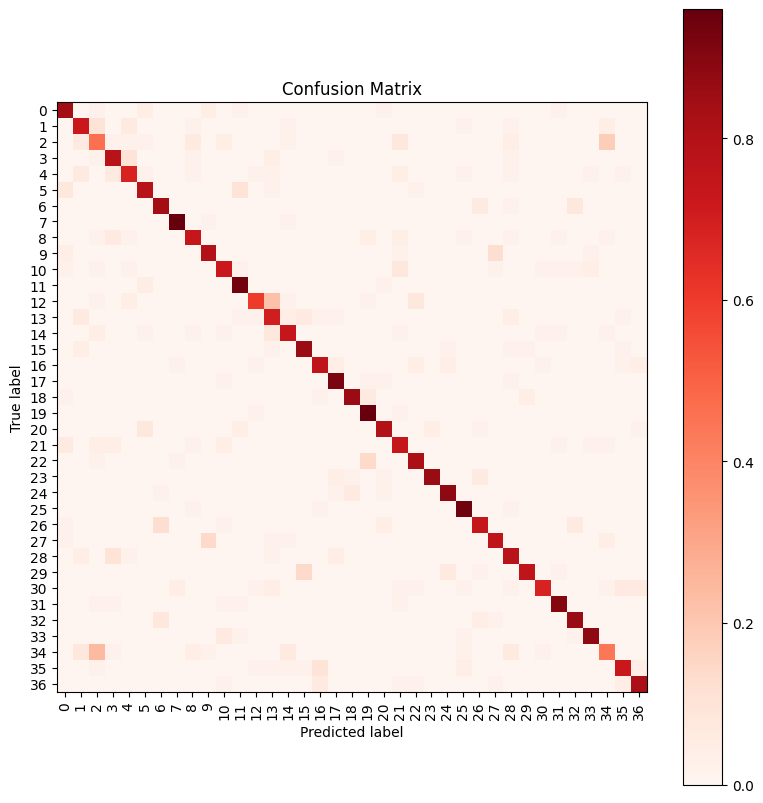

(<Figure size 814x814 with 2 Axes>,
 <Axes: title={'center': 'Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>)

In [46]:
plot_cm_sklearn(model_resnet, test_dataset, normalize='true', include_values=False, save_path="results/confusion_matrix_test_dataset.png")

# secondo allenamento

carico i pesi salvati e modifico la funzione di training per usare uno scheduler cosine annealing invece del onecyclelr, e faccio 50 epoche

In [ ]:
import torch

saved_model_path = "./resnet_18_complete_training_weights"

model_resnet = torch.load(saved_model_path, weights_only=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_resnet = model_resnet.to(device)

In [ ]:
# cosine annealing

def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs=10,
    T_max=None,
    eta_min=0.0,
    show_all_minibatches_loss=False,
):
    """
    Trains a PyTorch model and evaluates it on a validation set.

    Args:
        model (torch.nn.Module): The model to train.
        train_loader (DataLoader): DataLoader for the training dataset.
        val_loader (DataLoader): DataLoader for the validation dataset.
        criterion (torch.nn.Module): Loss function to optimize.
        optimizer (torch.optim.Optimizer): Optimizer for updating model weights.
        num_epochs (int): Number of epochs to train the model.
        T_max (int or None): Number of epochs for cosine annealing cycle (if None uses num_epochs).
        eta_min (float): Minimum learning rate for cosine annealing.
        show_all_minibatches_loss (bool): Can be 'no', 'brief', 'verbose'. Determines how many mini batch losses are printed

    Returns:
        tuple: A tuple containing:
            - train_losses (list): List of average training losses per epoch.
            - train_accuracies (list): List of training accuracies per epoch.
            - train_class_accuracies (list): List of per-class training accuracies per epoch.
            - val_losses (list): List of validation losses per epoch.
            - val_accuracies (list): List of validation accuracies per epoch.
            - val_class_accuracies (list): List of per-class validation accuracies per epoch.
            - train_epoch_times (list): Tempo (s) della sola fase di training per epoca.
            - total_epoch_times (list): Tempo (s) dell’intero ciclo per epoca (train + validazione/metriche).
    """
    train_losses = []
    train_accuracies = []
    train_class_accuracies = []
    val_losses = []
    val_accuracies = []
    val_class_accuracies = []
    train_epoch_times = []
    total_epoch_times = []

    # Get number of classes from the model's output layer
    num_classes = model.fc.out_features

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Setup Cosine Annealing LR scheduler (per-epoch)
    if T_max is None:
        T_max = num_epochs
    try:
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=T_max, eta_min=eta_min)
        scheduler_per_batch = False
    except Exception:
        scheduler = None
        scheduler_per_batch = False

    for epoch in range(num_epochs):
        t_epoch_start = time.time()

        # --- Training phase ---
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        train_class_correct = torch.zeros(num_classes, dtype=torch.long)
        train_class_total = torch.zeros(num_classes, dtype=torch.long)

        tot_batches = train_loader.__len__()
        t_train_start = time.time()
        for batch_idx, (batch_images, batch_labels) in enumerate(train_loader):
            batch_images = batch_images.to(device)
            batch_labels = batch_labels.to(device)

            # Zero gradients from previous iteration
            optimizer.zero_grad()

            outputs = model(batch_images)
            loss = criterion(outputs, batch_labels)
            if show_all_minibatches_loss != 'no':
                if show_all_minibatches_loss == 'verbose' or batch_idx in [40, 80]:
                    print(f"Batch {batch_idx + 1}/{tot_batches}: loss = {loss.item():.4f}")

            # Compute gradients
            loss.backward()

            # Update weights
            optimizer.step()

            # (removed per-batch scheduler.step; cosine annealing is stepped per-epoch)

            running_loss += loss.item()

            # Calculate training accuracy
            _, predicted = torch.max(outputs.data, 1)
            total_train += batch_labels.size(0)
            correct_train += (predicted == batch_labels).sum().item()

            # Per-class accuracy for training
            for i in range(batch_labels.size(0)):
                label = batch_labels[i]
                train_class_total[label] += 1
                if predicted[i] == label:
                    train_class_correct[label] += 1

        # Time
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        train_time = time.time() - t_train_start
        train_epoch_times.append(train_time)

        train_accuracy = 100 * correct_train / total_train
        train_loss = running_loss / len(train_loader)

        # Training Per-Class Accuracies
        epoch_train_class_accuracies = []
        for i in range(num_classes):
            if train_class_total[i] > 0:
                class_acc = train_class_correct[i].item() / train_class_total[i].item()
            else:
                class_acc = 0.0  # no samples for this class
            epoch_train_class_accuracies.append(class_acc)

        # --- Validation ---
        model.eval()
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0

        # Initialize per-class counters for validation
        val_class_correct = torch.zeros(num_classes, dtype=torch.long)
        val_class_total = torch.zeros(num_classes, dtype=torch.long)

        with torch.no_grad():  # don't compute gradients for validation
            for batch_images, batch_labels in val_loader:
                batch_images = batch_images.to(device)
                batch_labels = batch_labels.to(device)

                outputs = model(batch_images)
                loss = criterion(outputs, batch_labels)
                running_val_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                total_val += batch_labels.size(0)
                correct_val += (predicted == batch_labels).sum().item()

                # Validation Per-Class Accuracies
                for i in range(batch_labels.size(0)):
                    label = batch_labels[i]
                    val_class_total[label] += 1
                    if predicted[i] == label:
                        val_class_correct[label] += 1

        val_accuracy = 100 * correct_val / total_val
        val_loss = running_val_loss / len(val_loader)

        # Validation Per-Class Accuracies
        epoch_val_class_accuracies = []
        for i in range(num_classes):
            if val_class_total[i] > 0:
                class_acc = val_class_correct[i].item() / val_class_total[i].item()
            else:
                class_acc = 0.0  # no samples for this class
            epoch_val_class_accuracies.append(class_acc)

        # Time
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        total_time = time.time() - t_epoch_start
        total_epoch_times.append(total_time)

        # Step scheduler once per epoch (cosine annealing)
        if scheduler is not None:
            scheduler.step()

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        train_class_accuracies.append(epoch_train_class_accuracies)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)
        val_class_accuracies.append(epoch_val_class_accuracies)

        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.2f}%, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}% | "
              f"Epoch Time: {total_time:.2f}s")

        print('-'*20)

    return (train_losses, train_accuracies, train_class_accuracies,
            val_losses, val_accuracies, val_class_accuracies,
            train_epoch_times, total_epoch_times)

In [ ]:
lr = 3e-4
weight_decay = 1e-4

T_max = 50
eta_min = 1e-6

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model_resnet.parameters(), lr=lr, weight_decay=weight_decay)

train_losses, train_accuracies, train_class_accuracies, val_losses, val_accuracies, val_class_accuracies, train_epoch_times, total_epoch_times = train_model(
    model_resnet, train_loader, val_loader, criterion, optimizer, num_epochs=50,
    show_all_minibatches_loss='no', T_max=T_max, eta_min=eta_min
)

Epoch [1/50], Train Loss: 0.0294, Train Acc: 99.10%, Val Loss: 1.1343, Val Acc: 75.90% | Epoch Time: 47.09s
--------------------
Epoch [2/50], Train Loss: 0.0316, Train Acc: 99.07%, Val Loss: 1.1760, Val Acc: 75.74% | Epoch Time: 47.93s
--------------------
Epoch [3/50], Train Loss: 0.0344, Train Acc: 99.05%, Val Loss: 1.1652, Val Acc: 76.06% | Epoch Time: 47.90s
--------------------
Epoch [4/50], Train Loss: 0.0313, Train Acc: 98.88%, Val Loss: 1.1421, Val Acc: 76.17% | Epoch Time: 47.08s
--------------------
Epoch [5/50], Train Loss: 0.0297, Train Acc: 99.16%, Val Loss: 1.1857, Val Acc: 76.17% | Epoch Time: 47.33s
--------------------
Epoch [6/50], Train Loss: 0.0362, Train Acc: 98.72%, Val Loss: 1.2230, Val Acc: 76.17% | Epoch Time: 47.13s
--------------------
Epoch [7/50], Train Loss: 0.0411, Train Acc: 98.77%, Val Loss: 1.2170, Val Acc: 75.85% | Epoch Time: 47.25s
--------------------
Epoch [8/50], Train Loss: 0.0322, Train Acc: 99.10%, Val Loss: 1.2090, Val Acc: 75.52% | Epoch Ti